# Нагрузочное исследование очереди M/M/c

Для девяти устойчивых комбинаций оценивается установившийся режим после
отбрасывания разогрева. Расчёт сопоставляется с формулой Эрланга C.

In [1]:
using DrWatson
@quickactivate "EventSystemsStudy"
ENV["GKSwstype"] = "100"
include(srcdir("EventSystemsStudy.jl"))
using .EventSystemsStudy.QueueFlow, .EventSystemsStudy.EvidenceIO
using DataFrames, Plots

## План эксперимента

In [2]:
arrival_rates = [0.45, 0.70, 0.90]
channel_counts = [2, 3, 4]
clients, warmup = 15_000, 3_000
rows = NamedTuple[]

for (case, (lambda, c)) in enumerate(Iterators.product(arrival_rates, channel_counts))
    simulation = run_queue(; clients, channels=c, arrival_rate=lambda,
        service_rate=0.5, seed=700+case)
    estimate = queue_indicators(simulation; warmup)
    theory = erlang_c_indicators(lambda, 0.5, c)
    push!(rows, (; case, lambda, mu=0.5, c, rho=theory.rho,
        simulated_Wq=estimate.Wq, theoretical_Wq=theory.Wq,
        relative_error=abs(estimate.Wq-theory.Wq)/theory.Wq,
        simulated_Lq=estimate.Lq, theoretical_Lq=theory.Lq,
        utilization=estimate.utilization, little_error=estimate.little_queue_error))
end
summary = DataFrame(rows)
rename!(summary, :simulated_Wq=>:sim_Wq, :theoretical_Wq=>:theory_Wq,
    :simulated_Lq=>:sim_Lq, :theoretical_Lq=>:theory_Lq)
store_table("queue_load_study", "stationary_cases.csv", summary)

"/workspace/labs/lab07/project/data/queue_load_study/stationary_cases.csv"

## Сравнение

9×12 DataFrame
 Row │ case   lambda   mu       c      rho       sim_Wq      theory_Wq   relative_error  sim_Lq      theory_Lq   utilization  little_error
     │ Int64  Float64  Float64  Int64  Float64   Float64     Float64     Float64         Float64     Float64     Float64      Float64
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │     1     0.45      0.5      2  0.45      0.498834    0.507837        0.0177273   0.219678    0.228527       0.4407    -0.00479751
   2 │     2     0.7       0.5      2  0.7       1.98371     1.92157         0.0323399   1.40281     1.3451         0.703307   0.0142101
   3 │     3     0.9       0.5      2  0.9       9.24997     8.52632         0.0848725   8.31807     7.67368        0.895168  -0.00689876
   4 │     4     0.45      0.5      3  0.3       0.0644546   0.0666941       0.0335783   0.0289      0.0300124      0.302927  -0.000104589
   5 │     5     0.7

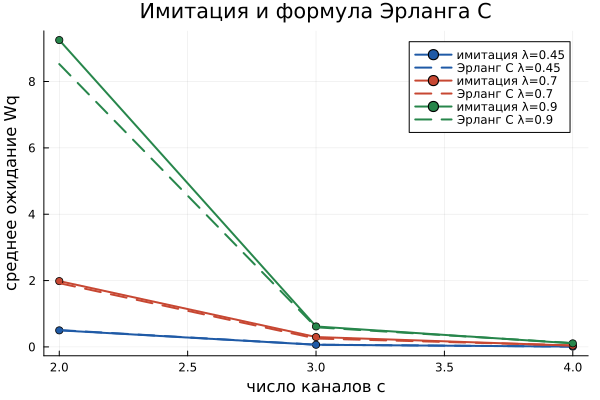

In [3]:
println(summary)
println("maximum relative Wq error = ", round(maximum(summary.relative_error), digits=4))
figure = queue_comparison_plot(summary)
store_figure("queue_load_study", "erlang_c_comparison.png", figure)
figure

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*